In [1]:
%load_ext water_quality.magics

In [2]:
from water_quality.logs import setup_logging
log = setup_logging()

In [3]:
import xarray as xr
from datacube import Datacube
# Useful later the year to plot for
year = "2023"

# Load the instrument data generated using the prototyping WP1.2 notebooks
wp_12_data_xr = xr.open_dataset("tss_chla.nc", engine='h5netcdf')
wp_12_data_xr

2026-02-22 19:18:05,133 numexpr.utils [INFO]: NumExpr defaulting to 4 threads.


<xarray.Dataset> Size: 83MB
Dimensions:       (time: 25, y: 170, x: 76, tss_measure: 17, chla_measure: 15)
Coordinates:
  * time          (time) datetime64[ns] 200B 2000-07-01T23:59:59.999999 ... 2...
  * y             (y) float64 1kB 5.731e+04 5.753e+04 ... 9.427e+04 9.449e+04
  * x             (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
  * tss_measure   (tss_measure) <U14 952B 'ndssi_rg_msi' ... 'spm_qiu_msi'
  * chla_measure  (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modis2b_tm'
    spatial_ref   int32 4B ...
Data variables:
    tss           (time, y, x, tss_measure) float64 44MB ...
    chla          (time, y, x, chla_measure) float64 39MB ...
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

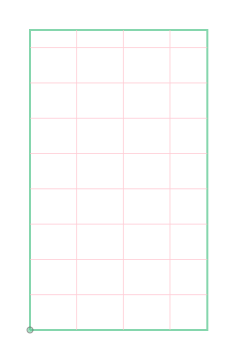

In [4]:
tile_geobox = wp_12_data_xr.odc.geobox
tile_geobox

In [6]:
wq_var_name = "chla"

In [7]:
bands = wp_12_data_xr[f"{wq_var_name}_measure"].values.tolist()
bands

['ndci_msi54',
 'ndci_msi64',
 'ndci_msi74',
 'ndci_tm43',
 'ndci_oli54',
 'chla_toming_msi',
 'chla_3bda_msi',
 'chla_3bda_oli',
 'chla_3bda_tm',
 'chla_tebbs_msi',
 'chla_tebbs_oli',
 'chla_tebbs_tm',
 'chla_meris2b_msi',
 'chla_modis2b_msi',
 'chla_modis2b_tm']

In [8]:
import rioxarray

filepath_template = "test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_band.tif"
file_list = [filepath_template.replace("band", band) for band in bands]

from pathlib import Path

# Initialize the nested dictionary
wq_ds = {}

# Filter the zip to only include existing files
wq_ds[wq_var_name] = xr.Dataset({
    name: rioxarray.open_rasterio(path).squeeze(drop=True)
    for name, path in zip(bands, file_list)
    if Path(path).exists()  # Only process if file exists
})

wq_ds[wq_var_name]

<xarray.Dataset> Size: 1MB
Dimensions:           (x: 76, y: 170)
Coordinates:
  * x                 (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
  * y                 (y) float64 1kB 5.731e+04 5.753e+04 ... 9.449e+04
    spatial_ref       int64 8B 0
Data variables:
    ndci_msi54        (y, x) float64 103kB ...
    ndci_msi64        (y, x) float64 103kB ...
    ndci_msi74        (y, x) float64 103kB ...
    ndci_oli54        (y, x) float64 103kB ...
    chla_toming_msi   (y, x) float64 103kB ...
    chla_3bda_msi     (y, x) float64 103kB ...
    chla_3bda_oli     (y, x) float64 103kB ...
    chla_tebbs_msi    (y, x) float64 103kB ...
    chla_tebbs_oli    (y, x) float64 103kB ...
    chla_meris2b_msi  (y, x) float64 103kB ...
    chla_modis2b_msi  (y, x) float64 103kB ...

In [9]:
# new bands list

bands = list(wq_ds[wq_var_name].data_vars)
bands

['ndci_msi54',
 'ndci_msi64',
 'ndci_msi74',
 'ndci_oli54',
 'chla_toming_msi',
 'chla_3bda_msi',
 'chla_3bda_oli',
 'chla_tebbs_msi',
 'chla_tebbs_oli',
 'chla_meris2b_msi',
 'chla_modis2b_msi']

In [10]:
def required_counts(da_):
    valid_pixels = da_.count().item()
    total_pixels = da_.size
    return f"{valid_pixels} valid_pixels \n {total_pixels} total pixels"

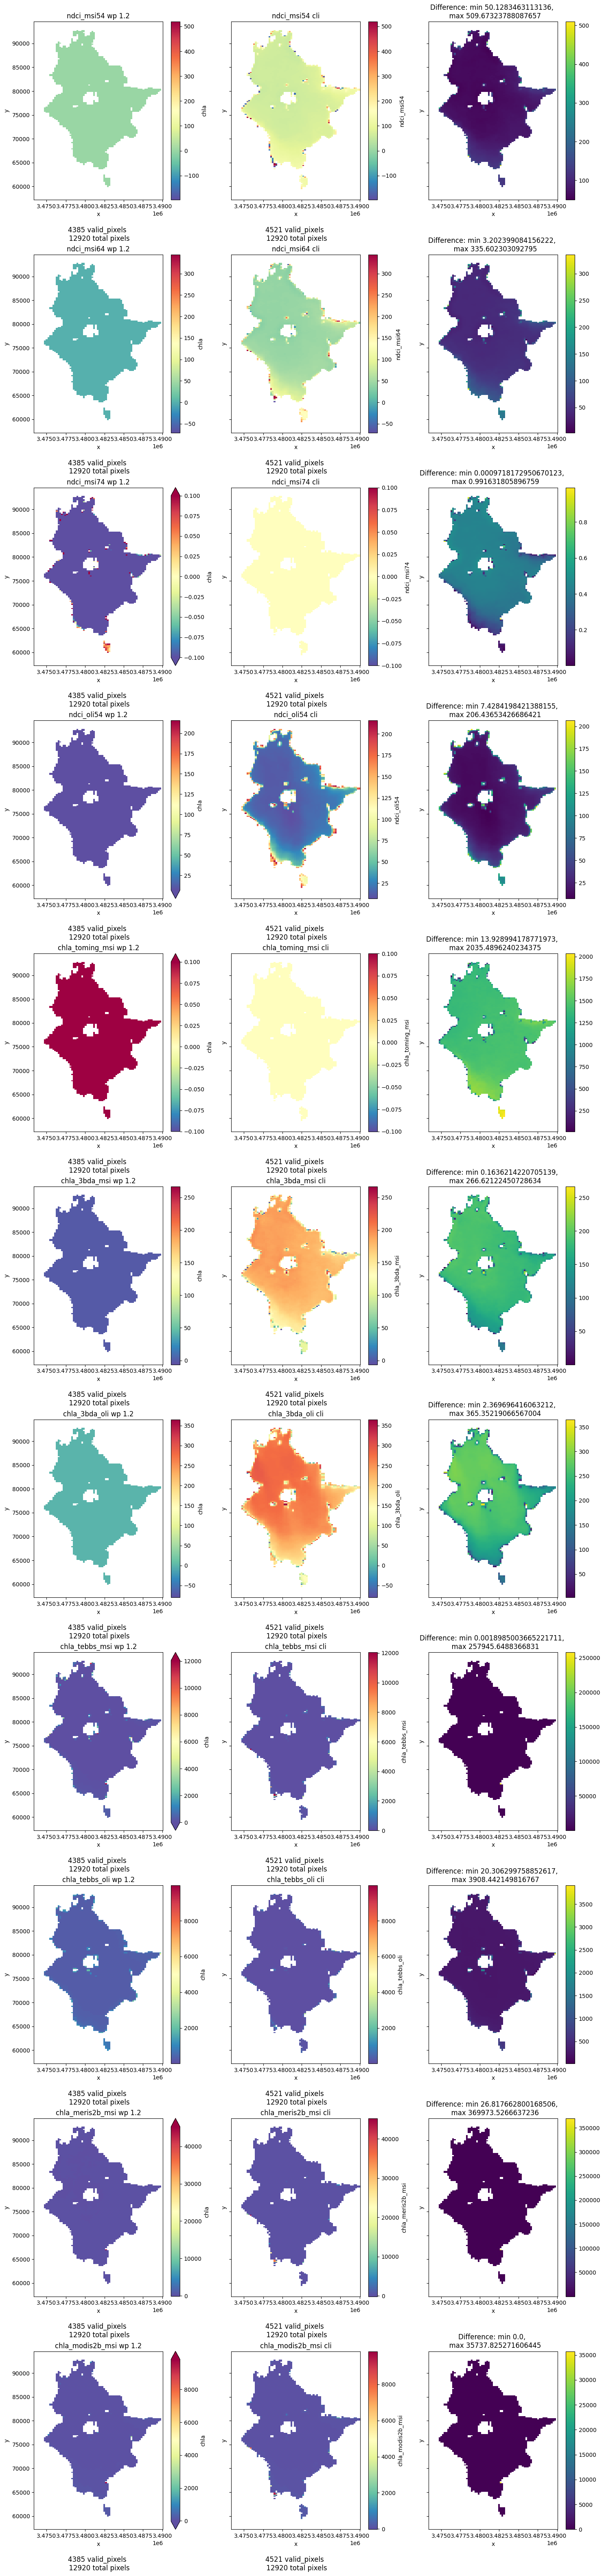

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


n_variables = len(bands)
n_plots_per_variable = 3
ncols = n_plots_per_variable  # columns for ref, da, and diff plots
nrows = n_variables           # rows for each variable

fig, axs = plt.subplots(nrows, ncols, sharey=True, figsize=(15, 6 * nrows))

cmap = 'Spectral_r'

for var in bands:
    i = bands.index(var)
    ref_da = wp_12_data_xr[wq_var_name].sel({f"{wq_var_name}_measure":var}).sel(time=year)
    da = wq_ds[wq_var_name][var]
    diff = np.abs(ref_da - da)
    
    min_diff = diff.min().item()
    max_diff = diff.max().item() 

    # --- Plotting within the loop, using the row index 'i' ---
    # Plot 'ref_da' on the first column of the current row
    norm = mcolors.Normalize(vmin=da.min(), vmax=da.max())

    ref_da.plot( cmap=cmap, norm=norm, ax=axs[i, 0])
    axs[i, 0].text(0.5, -0.15, required_counts(ref_da), 
                transform=axs[i, 0].transAxes, 
                ha='center', va='top', fontsize=12)
    axs[i, 0].set_title(f"{var} wp 1.2")

    # Plot 'da' on the second column of the current row
    da.plot( cmap=cmap, norm=norm, ax=axs[i, 1])
    axs[i, 1].text(0.5, -0.15, required_counts(da), 
                transform=axs[i, 1].transAxes, 
                ha='center', va='top', fontsize=12)
    axs[i, 1].set_title(f"{var} cli")

    # Plot 'diff' on the third column of the current row
    diff.plot(ax=axs[i, 2])
    axs[i, 2].set_title(f"Difference: min {min_diff}, \n  max {max_diff}")


        
plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect argument is used to make space for suptitle
plt.savefig(f'{wq_var_name}_comparison.png', dpi=200)

# Optional: Display the final plot
plt.show()